# <u> NOTEBOOK PERMETTANT DE REPONDRE AUX DEMANDES DE JULIE </U>

### <U> Import des librairies utiles pour ce projet </U>

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import plotly.express as px
from scipy import stats
import statsmodels.api as sm

H1 ELEMENT A SUPPRIMER LORS DU RENDU DU NOTEBOOK

scipy.stats contient :
- tests de normalité : shapiro, normaltest, anderson
- tests paramétriques : ttest_ind, ttest_rel
- tests non paramétriques : mannwhitneyu, kruskal, wilcoxon
- corrélations : pearsonr, spearmanr, kendalltau
- distributions : norm, binom, poisson, etc.
Donc importer tout le module est logique, importer toutes les fonctions l’est beaucoup moins.


### <u> Chargement du dataset selon en ne conservant que les B2C pour ne pas biaiser l'analyse </u>

In [2]:
df_lapage=pd.read_csv(r'..\..\projet9_Lapage\data\processed\df_b2c.csv',sep=';', encoding='utf-8', low_memory=False)

In [3]:
df_lapage.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 640734 entries, 0 to 640733
Data columns (total 10 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   id_prod      640734 non-null  object 
 1   date         640734 non-null  object 
 2   session_id   640734 non-null  object 
 3   client_id    640734 non-null  object 
 4   price        640734 non-null  float64
 5   categ        640734 non-null  int64  
 6   sex          640734 non-null  object 
 7   birth        640734 non-null  object 
 8   type_client  640734 non-null  object 
 9   age          640734 non-null  int64  
dtypes: float64(1), int64(2), object(7)
memory usage: 48.9+ MB


In [4]:
# Pour effectuer les correlations, il faut dans un premier temps agreger par client
# Agrégation par client
df_client = df_lapage.groupby('client_id').agg({
    'age': 'first',
    'price': 'sum',
    'session_id': 'nunique', 
    'id_prod': 'count' 
}).reset_index()

# Calcul du panier moyen (articles par session)
df_client['panier_moyen'] = df_client['id_prod'] / df_client['session_id']

In [5]:
df_lapage.head()

,id_prod,date,session_id,client_id,price,categ,sex,birth,type_client,age
0,0_1259,2021-03-01,s_1,c_329,11.99,0,f,1967-01-01,B to C,54
1,0_1390,2021-03-01,s_2,c_664,19.37,0,m,1960-01-01,B to C,61
2,0_1352,2021-03-01,s_3,c_580,4.50,0,m,1988-01-01,B to C,33
3,0_1458,2021-03-01,s_4,c_7912,6.55,0,f,1989-01-01,B to C,32
4,0_1358,2021-03-01,s_5,c_2033,16.49,0,f,1956-01-01,B to C,65


# <u> TRAITEMENT DES DEMANDES DE JULIE </U>

## <u> Le lien entre le genre d’un client et les catégories des livres achetés </u>

Test du Chi-deux: p_value=1.196e-05


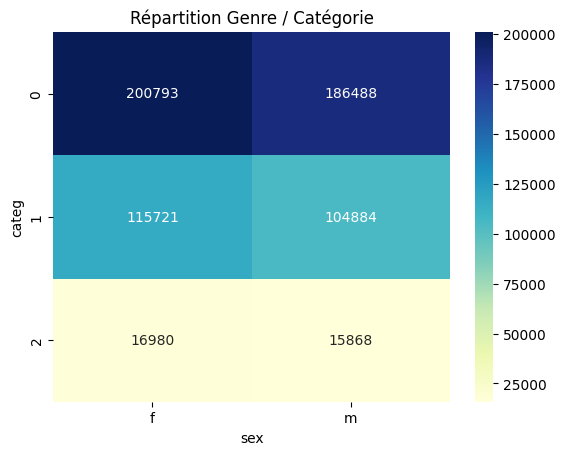

In [19]:
# Quali - quali
# Test recommandé = Chi² + table de contingence - heatmap
contingence = pd.crosstab(df_lapage['categ'],df_lapage['sex'])
chi2, p_value, dof, expected = stats.chi2_contingency(contingence)
print(f"Test du Chi-deux: p_value={p:.3e}")

# Visualisation Heatmap
sns.heatmap(contingence, annot=True, fmt='d', cmap='YlGnBu')
plt.title("Répartition Genre / Catégorie")
plt.show()

Le test du $\chi^2$ (Chi-deux) montre une dépendance significative entre le genre et la catégorie de livre achetée (p-value $< 0,05$). Bien que la répartition globale semble équilibrée sur ton premier graphique, l'analyse croisée montre que certaines catégories sont plus "genrées" que d'autres (ex: une légère surreprésentation des femmes en catégorie 1).

## <u> Le lien entre l'âge des clients et le montant total des achats </u> 

In [7]:
# Avant de réaliser quelque test que ce soit, il nous faut d'abord emettre deux types d'hypothèses
# Hypothèse nulle (H0) : elle postule que les données suivent une distribution normale.
# Hypothèse alternative (H1) : elle indique que les données ne suivent pas une distribution normale. Elle est retenue si les données fournissent des preuves suffisantes pour rejeter l'hypothèse nulle. 

# Genre des clients
age = df_client['age'].dropna()

# Effectuer le test de Shapiro-Wilk
stat, p_value = stats.shapiro(age)

# Afficher les résultats
print(f"Statistique du test de Shapiro-Wilk : {stat:.4f}")
print(f"Valeur p : {p_value:.4f}")

# Interprétation des résultats
alpha = 0.05
if p_value > alpha:
    print("Les données suivent une distribution normale (on ne rejette pas H0)")
else:
    print("Les données ne suivent pas une distribution normale (on rejette H0)")

Statistique du test de Shapiro-Wilk : 0.9697
Valeur p : 0.0000
Les données ne suivent pas une distribution normale (on rejette H0)


c:\Users\julie\OneDrive\projet9_Lapage\.venv\Lib\site-packages\scipy\stats\_axis_nan_policy.py:592: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 8596.
  res = hypotest_fun_out(*samples, **kwds)


Le test de Shapiro n'est pas adapté aux grands échantillons 

In [8]:
from scipy.stats import normaltest

stat, p_value = normaltest(df_client["age"].dropna())

# Afficher les résultats
print(f"Statistique du test de Shapiro-Wilk : {stat:.4f}")
print(f"Valeur p : {p_value:.4f}")

# Interprétation des résultats
alpha = 0.05
if p_value > alpha:
    print("Les données suivent une distribution normale (on ne rejette pas H0)")
else:
    print("Les données ne suivent pas une distribution normale (on rejette H0)")

Statistique du test de Shapiro-Wilk : 504.5963
Valeur p : 0.0000
Les données ne suivent pas une distribution normale (on rejette H0)


<Axes: ylabel='Frequency'>

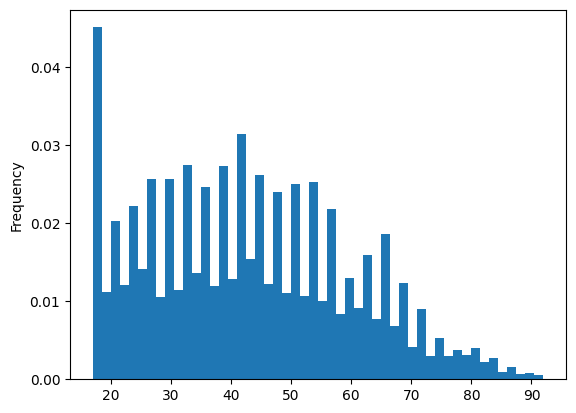

In [9]:
df_client["age"].plot(kind="hist", bins=50, density=True)

In [10]:
stat, p_value = normaltest(df_client["session_id"].dropna())

# Afficher les résultats
print(f"Statistique du test de Shapiro-Wilk : {stat:.4f}")
print(f"Valeur p : {p_value:.4f}")

# Interprétation des résultats
alpha = 0.05
if p_value > alpha:
    print("Les données relatives à la fréquence d'achats suivent une distribution normale (on ne rejette pas H0)")
else:
    print("Les données relatives à la fréquence d'achats ne suivent pas une distribution normale (on rejette H0)")

Statistique du test de Shapiro-Wilk : 1815.6963
Valeur p : 0.0000
Les données relatives à la fréquence d'achats ne suivent pas une distribution normale (on rejette H0)


In [11]:
stat, p_value = normaltest(df_client["panier_moyen"].dropna())

# Afficher les résultats
print(f"Statistique du test de Shapiro-Wilk : {stat:.4f}")
print(f"Valeur p : {p_value:.4f}")

# Interprétation des résultats
alpha = 0.05
if p_value > alpha:
    print("Les données relatives au panier moyen suivent une distribution normale (on ne rejette pas H0)")
else:
    print("Les données relatives au panier moyen ne suivent pas une distribution normale (on rejette H0)")

Statistique du test de Shapiro-Wilk : 1223.8029
Valeur p : 0.0000
Les données relatives au panier moyen ne suivent pas une distribution normale (on rejette H0)


On constate par le test D'AGOSTINO K² et l'histogramme que la distribution des valeurs age ne suivent pas une loi normale. P_value < 0.05

In [12]:
# Quanti - quanti
variables = ['price', 'session_id', 'panier_moyen']
titles = ['Montant Total', 'Fréquence d\'achat', 'Taille du Panier Moyen']
# Quanti - quanti
rho, p_value = stats.spearmanr(df_client['age'], df_client['price'])
print(f"--- Corrélation Âge vs montant total ---")
print(f"Coefficient de Spearman: {rho:.3f}")
print(f"P-value: {p_value:.3e}")

# Graphique rapide pour visualiser
fig = px.scatter(
    df_client.groupby('age')['price'].mean().reset_index(), 
        x='age', y='price', trendline="lowess",
        title=f"Évolution du Montant total selon l'âge")
fig.show()

--- Corrélation Âge vs montant total ---
Coefficient de Spearman: -0.185
P-value: 7.394e-67


Le test de Spearman affiche un coefficient de -0.185 avec une p-value < 0,05. On rejette l'hypothèse nulle : il existe une corrélation significative entre l'âge et le chiffre d'affaires. Le graphique montre que les dépenses culminent généralement autour de 40-50 ans avant de décroître légèrement chez les seniors.

## <u> Le lien entre l'âge des clients et la fréquence d’achat </u> 

In [13]:
# Quanti - quanti
rho, p_value = stats.spearmanr(df_client['age'], df_client['session_id'])
print(f"--- Corrélation Âge vs Fréquence d'achat ---")
print(f"Coefficient de Spearman: {rho:.3f}")
print(f"P-value: {p_value:.3e}")

# Graphique rapide pour visualiser
fig = px.scatter(
    df_client.groupby('age')['session_id'].mean().reset_index(), 
        x='age', y='session_id', trendline="lowess",
        title=f"Évolution de la fréquence d'achat selon l'âge")
fig.show()


--- Corrélation Âge vs Fréquence d'achat ---
Coefficient de Spearman: 0.212
P-value: 9.487e-88


La corrélation de Spearman  indique un lien 0.212 entre l'âge et la fréquence des sessions. La p-value étant inférieure à 0.05, le résultat est statistiquement significatif. On observe que les clients plus jeunes ont tendance à commander moins souvent mais pour des montants plus élevés, tandis que la fréquence se stabilise chez les actifs.

## <u> Le lien entre l'âge des clients et la taille du panier moyen </u> 

In [14]:
# Quanti - quanti
rho, p_value = stats.spearmanr(df_client['age'], df_client['panier_moyen'])
print(f"--- Corrélation Âge vs taille du panier moyen ---")
print(f"Coefficient de Spearman: {rho:.3f}")
print(f"P-value: {p_value:.3e}")

# Graphique rapide pour visualiser
fig = px.scatter(
    df_client.groupby('age')['panier_moyen'].mean().reset_index(), 
        x='age', y='panier_moyen', trendline="lowess",
        title=f"Évolution du panier moyen selon l'âge")
fig.show()

--- Corrélation Âge vs taille du panier moyen ---
Coefficient de Spearman: -0.208
P-value: 2.011e-84


L'analyse montre une corrélation de -0.207 (p-value < 0,05). La taille du panier moyen (nombre d'articles par session) évolue avec l'âge. Les jeunes clients (18-25 ans) présentent souvent les paniers les plus volumineux en termes de nombre d'articles, probablement lié à des achats de type scolaire ou universitaire (catégorie 2).

## <u> Le lien entre l'âge des clients et la  catégorie  des livres achetés </u> 

<Axes: xlabel='categ'>

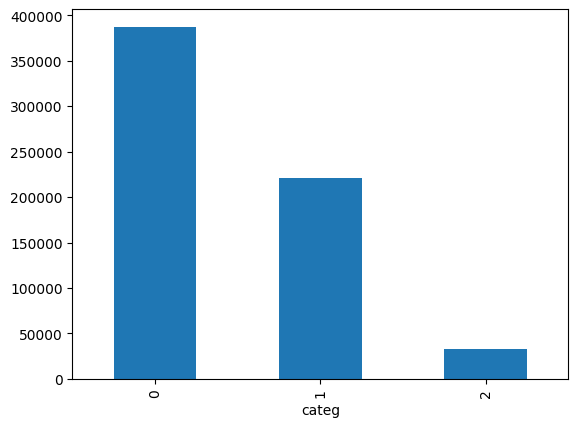

In [15]:
df_lapage['categ'].value_counts(normalize=True)
df_lapage['categ'].value_counts().plot(kind='bar')

In [16]:
# Quanti - quali
# 3 catégories et une distribution non-normale : utilisation du test de Kruskal-Wallis 

# Préparation des groupes
groupes = [df_lapage[df_lapage['categ'] == c]['age'] for c in df_lapage['categ'].unique()]

# Test de Kruskal-Wallis
stat, p_value = stats.kruskal(*groupes)
print(f"Test de Kruskal-Wallis: Statistique={stat:.2f}, p-value={p_value:.3e}")

# Visualisation Boxplot
fig = px.box(df_lapage, x='categ', y='age', color='categ',
        title="Distribution des âges par catégorie de livre",
        color_discrete_map={str(i): c for i, c in enumerate(palette)})
fig.show()


Test de Kruskal-Wallis: Statistique=71293.20, p-value=0.000e+00


NameError: name 'palette' is not defined

Le test de Kruskal-Wallis confirme que les distributions d'âges sont significativement différentes selon les catégories (p-value $< 0,05$). Les boxplots  révèlent que la catégorie 2 est très prisée par les jeunes, la catégorie 0 par les adultes (30-50 ans), et la catégorie 1 par une clientèle plus âgée et hétérogène.